In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


In [2]:
import pandas as pd
df = pd.read_csv("Mall_Customers.csv")

In [3]:
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [4]:
# Drop CustomerID
df = df.drop('CustomerID', axis=1)

# Encode Gender
df['Gender'] = df['Gender'].map({'Male':0, 'Female':1})

# Select features
X = df[['Age','Annual Income (k$)','Spending Score (1-100)','Gender']]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


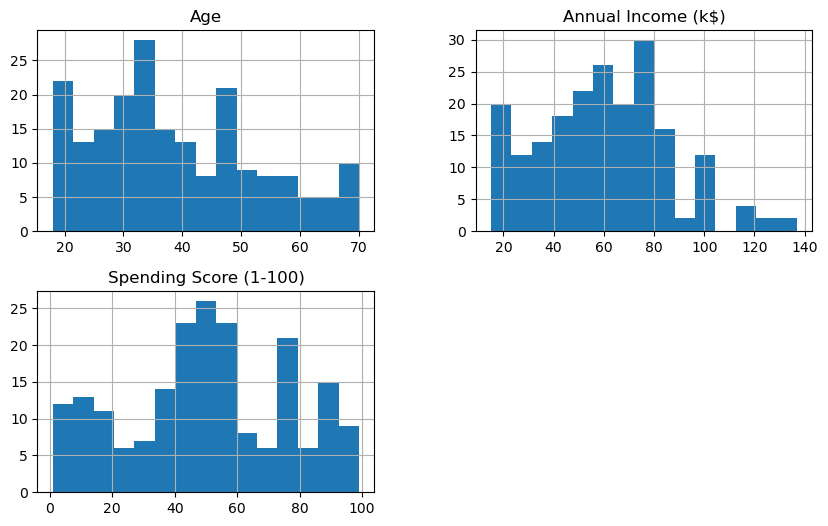

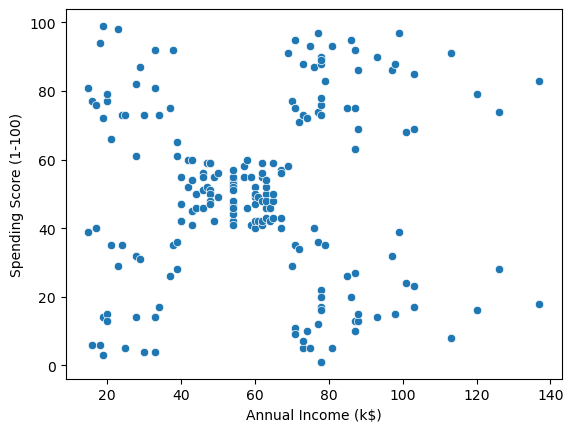

In [5]:
 # Histograms
df[['Age','Annual Income (k$)','Spending Score (1-100)']].hist(bins=15, figsize=(10,6))
plt.show()

# Income vs Spending Score
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)
plt.show()


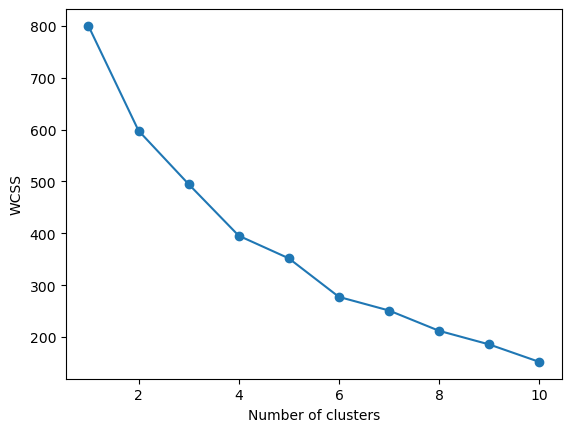

In [6]:
# Elbow Method
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# Fit final model (choose k=5 for example)
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)




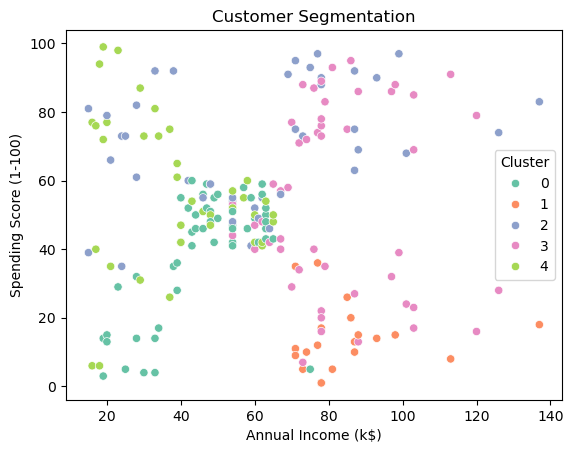

In [7]:
sns.scatterplot(x=df['Annual Income (k$)'], 
                y=df['Spending Score (1-100)'], 
                hue=df['Cluster'], palette='Set2')
plt.title("Customer Segmentation")
plt.show()


In [8]:
 # Cluster profiles
cluster_summary = df.groupby('Cluster').mean()
print(cluster_summary)


           Gender        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                 
0        0.490196  56.470588           46.098039               39.313725
1        0.000000  39.500000           85.150000               14.050000
2        0.000000  28.690476           60.904762               70.238095
3        1.000000  37.897959           82.122449               54.448980
4        1.000000  27.315789           38.842105               56.210526
